In [1]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_excel("Training_Providers.xlsx")
df.columns = df.columns.str.strip()

print(df.columns.tolist(), "\n")
print(df.head())

['ID', 'Service', 'Institution', 'Website', 'Type', 'Fee Structure'] 

   ID        Service                Institution  \
0   1  Deep Cleaning  Multiple Facility Service   
1   2  Deep Cleaning                 IHTS Nepal   
2   3  Deep Cleaning                Sajilo Sewa   
3   4  Deep Cleaning                      Kucho   
4   5  Deep Cleaning                  KTS Nepal   

                                Website                Type Fee Structure  
0  https://multiplefacilityservice.com/   Training Provider          Paid  
1                  https://ihts.edu.np/  Training Institute          Paid  
2           https://www.sajilosewa.com/   Training Provider          Paid  
3            https://kucho.co/services/   Training Provider          Paid  
4             https://www.ktsnepal.com/  Training Institute          Paid  


In [3]:
# Quick check on data shape
print(f"Total records: {len(df)}\n")
print(df["Service"].value_counts(), "\n")
print(df["Type"].value_counts(), "\n")
print(df["Fee Structure"].value_counts(), "\n")

Total records: 215

Service
Electrical Repair          14
Plumbing Repair            13
AC Services                10
Deep Cleaning               9
Masonry Repair              9
Bridal Makeup               8
Spa at Home                 8
Refrigerator Repair         8
Computer Repair             7
Handyman                    7
Salon at Home               7
Chef at Home                6
Painting                    6
Aluminium Fabrication       6
Carpentry                   6
Home Automation             6
Massage Therapy             6
Tiling                      6
AirBnB Maintenance          5
Water Tank Cleaning         5
EV Charger Installation     5
False Ceiling               5
Garden Care                 5
Drywall Repair              5
Septic Tank Cleaning        5
Washing Machine Repair      5
CCTV Services               4
RO Water Purifying          4
Geyser Repair               3
Indoor Planting             3
Parqueting                  3
Home Renovation             3
Modular Kitc

### Chart 1 - Number of Training Providers per Service Category

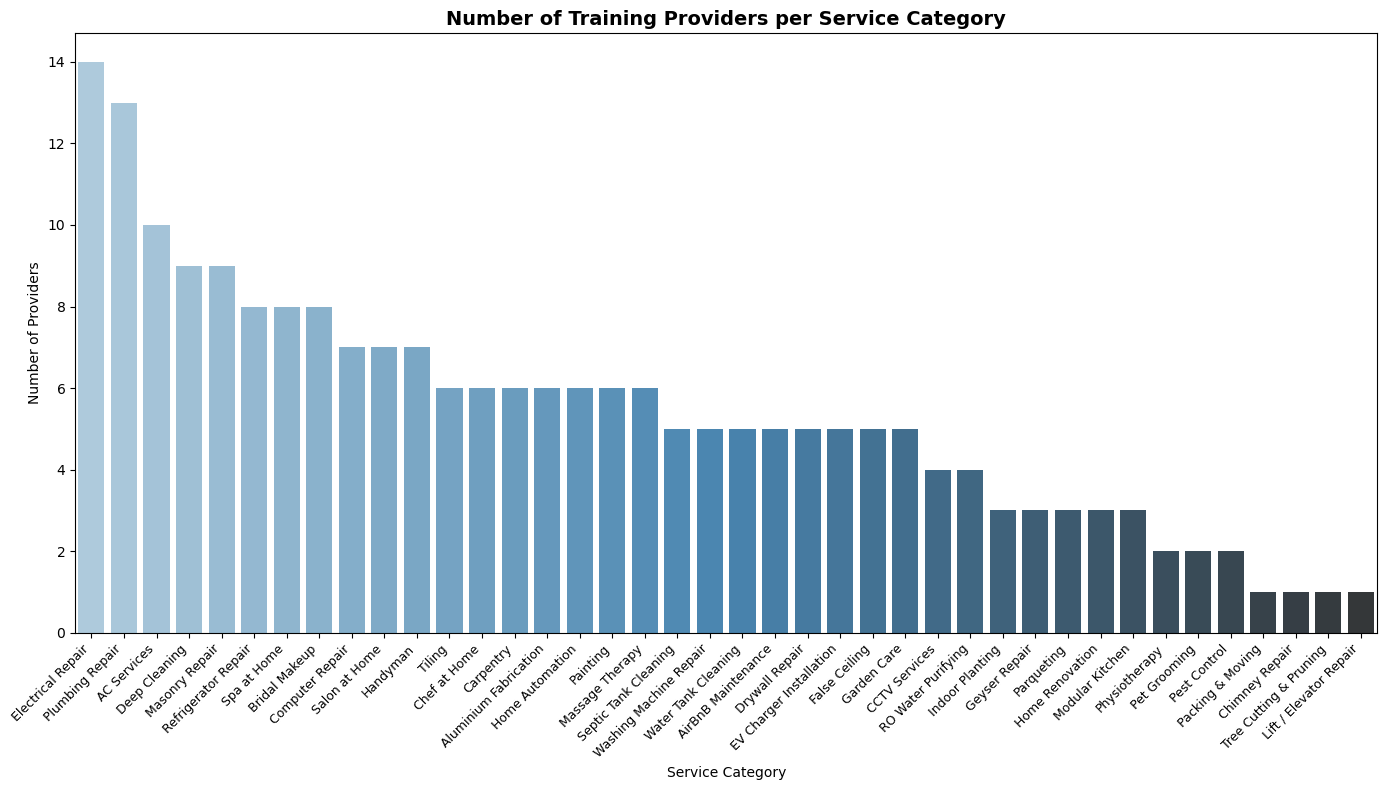

In [4]:
provider_counts = df.groupby("Service")["Institution"].count().reset_index()
provider_counts.columns = ["Service", "Provider Count"]
provider_counts = provider_counts.sort_values("Provider Count", ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(data=provider_counts, x="Service", y="Provider Count", hue="Service", palette="Blues_d", legend=False)

plt.title("Number of Training Providers per Service Category", fontsize=14, fontweight="bold")
plt.xlabel("Service Category")
plt.ylabel("Number of Providers")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2 - Top 10 Most Active Training Institutions

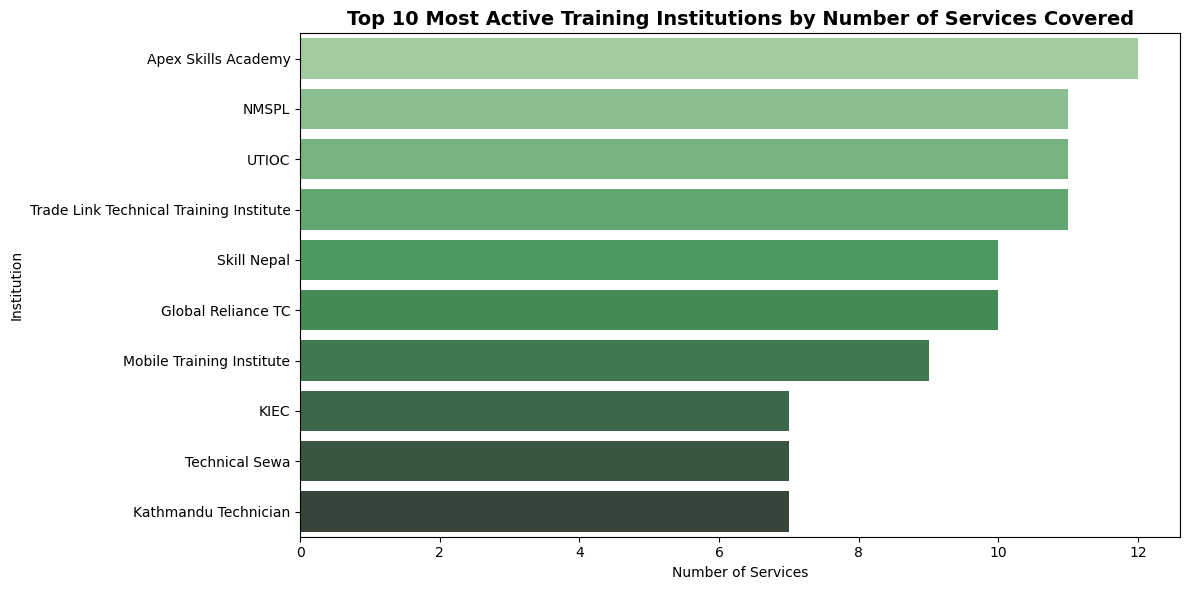

In [5]:
top_institutions = df.groupby("Institution")["Service"].count().reset_index()
top_institutions.columns = ["Institution", "Service Count"]
top_institutions = top_institutions.sort_values("Service Count", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_institutions, x="Service Count", y="Institution", hue="Institution", palette="Greens_d", legend=False)

plt.title("Top 10 Most Active Training Institutions by Number of Services Covered", fontsize=14, fontweight="bold")
plt.xlabel("Number of Services")
plt.ylabel("Institution")
plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 3 - Share of Paid vs Free or Subsidized Training 

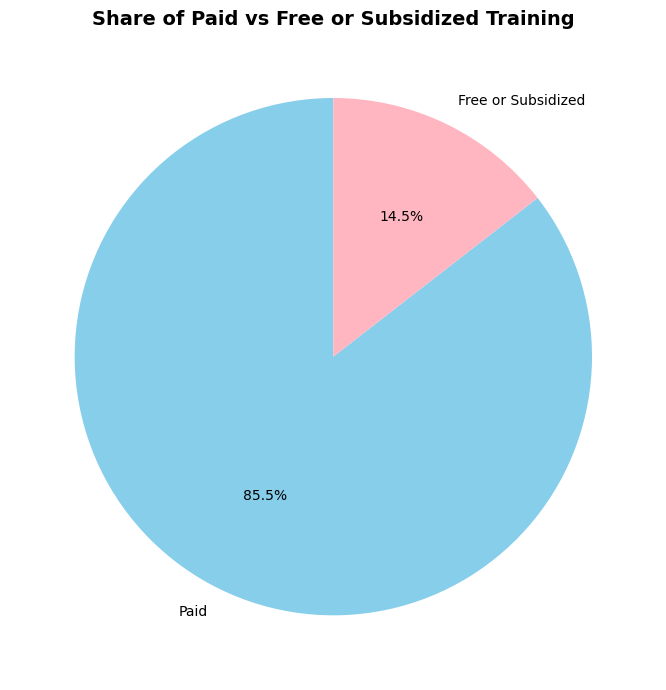

In [6]:
cost_counts = df[df["Fee Structure"].isin(["Paid", "Free or Subsidized"])]["Fee Structure"].value_counts().reset_index()
cost_counts.columns = ["Cost Type", "Count"]

plt.figure(figsize=(7, 7))
plt.pie(cost_counts["Count"], labels=cost_counts["Cost Type"], autopct="%1.1f%%",
        colors=["skyblue", "#FFB6C1"], startangle=90,
        pctdistance=0.6, labeldistance=1.1)

plt.title("Share of Paid vs Free or Subsidized Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 4 - Distribution of Training Providers by Type

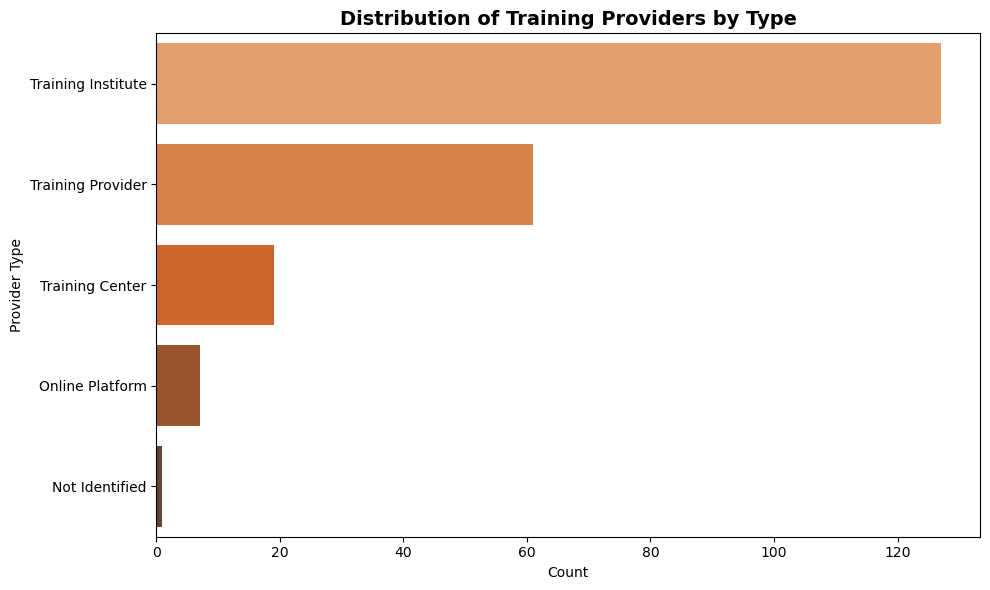

In [7]:
type_counts = df["Type"].value_counts().reset_index()
type_counts.columns = ["Type", "Count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=type_counts, x="Count", y="Type", hue="Type", palette="Oranges_d", legend=False)

plt.title("Distribution of Training Providers by Type", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Provider Type")
plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 5 - Paid vs Free or Subsidized Split per Service Category

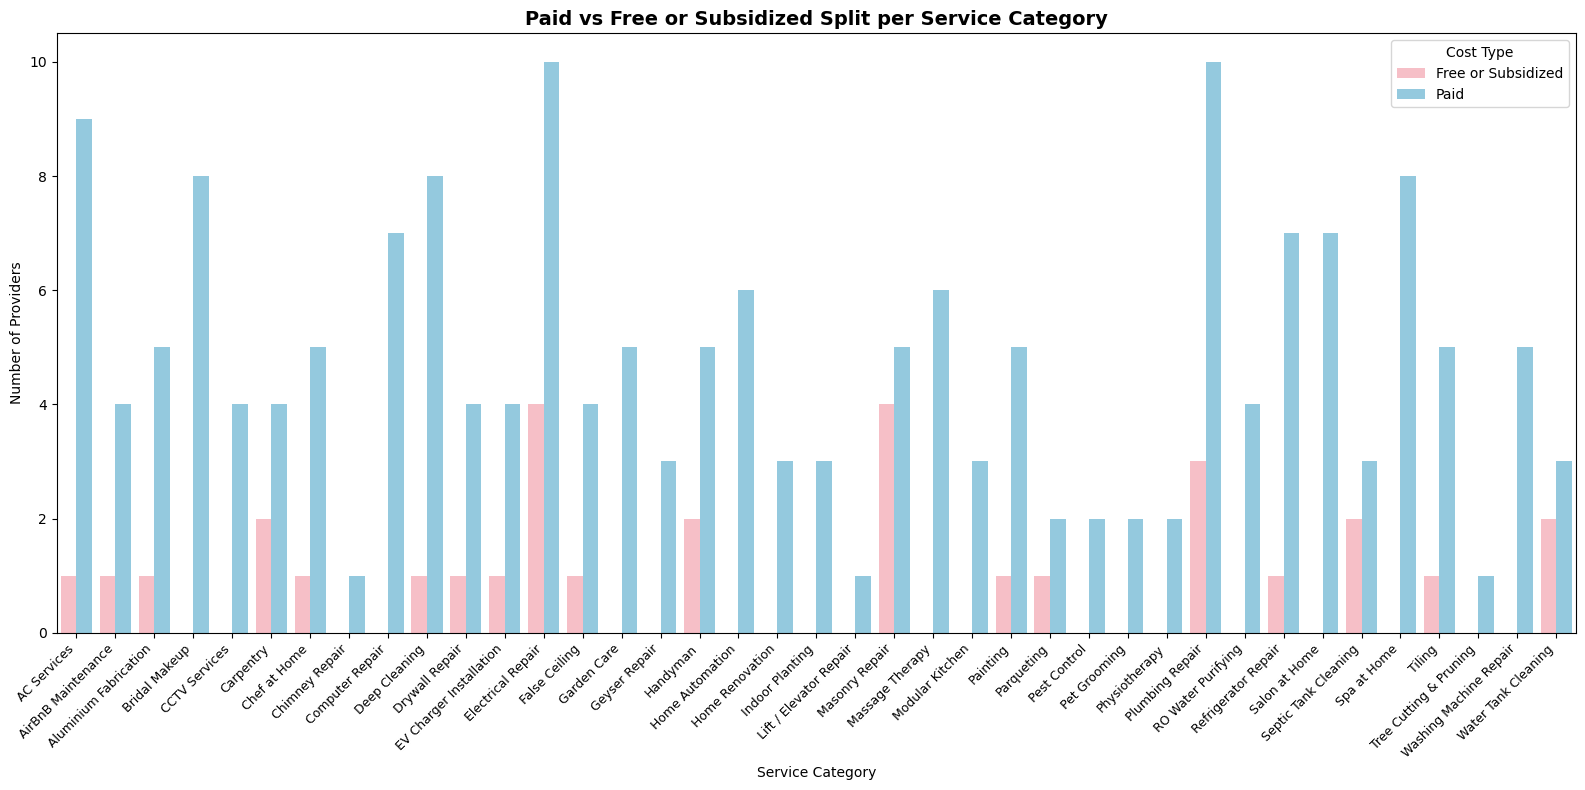

In [8]:
df_filtered = df[df["Fee Structure"].isin(["Paid", "Free or Subsidized"])]
cost_service = df_filtered.groupby(["Service", "Fee Structure"]).size().reset_index()
cost_service.columns = ["Service", "Cost Type", "Count"]

plt.figure(figsize=(16, 8))
sns.barplot(data=cost_service, x="Service", y="Count", hue="Cost Type", palette={"Paid": "skyblue", "Free or Subsidized": "#FFB6C1"})

plt.title("Paid vs Free or Subsidized Split per Service Category", fontsize=14, fontweight="bold")
plt.xlabel("Service Category")
plt.ylabel("Number of Providers")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.legend(title="Cost Type")
plt.tight_layout()
plt.savefig("chart5.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 6 - Services with Least Training Coverage

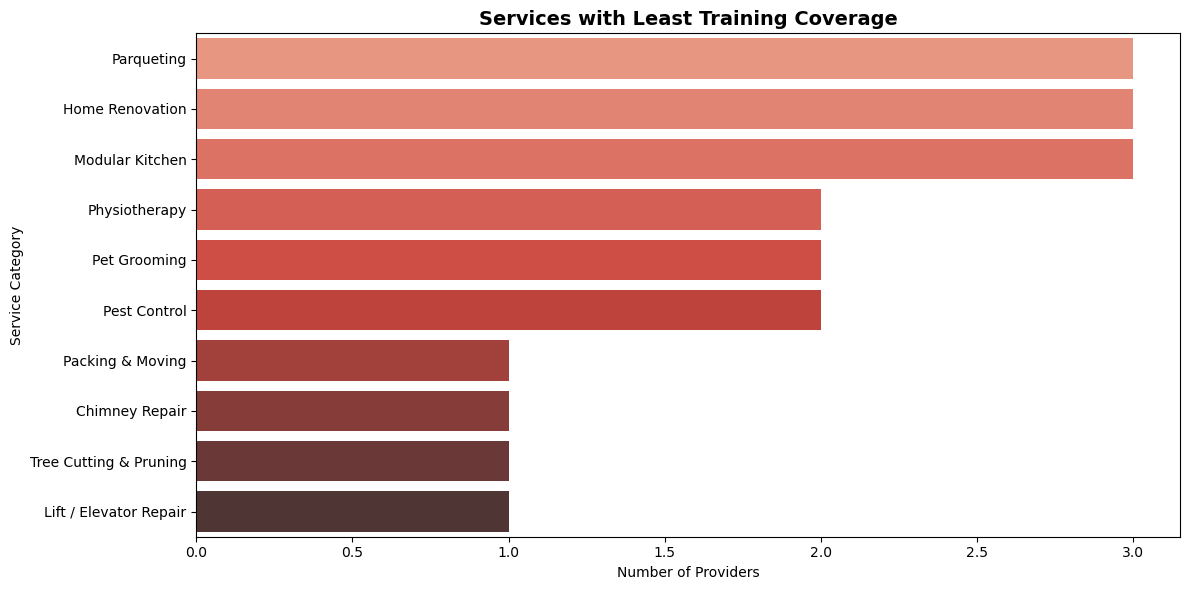

In [9]:
low_coverage = provider_counts.tail(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=low_coverage, x="Provider Count", y="Service", hue="Service", palette="Reds_d", legend=False)

plt.title("Services with Least Training Coverage", fontsize=14, fontweight="bold")
plt.xlabel("Number of Providers")
plt.ylabel("Service Category")
plt.tight_layout()
plt.savefig("chart6.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 7 - Heatmap of Institution vs Service Coverage

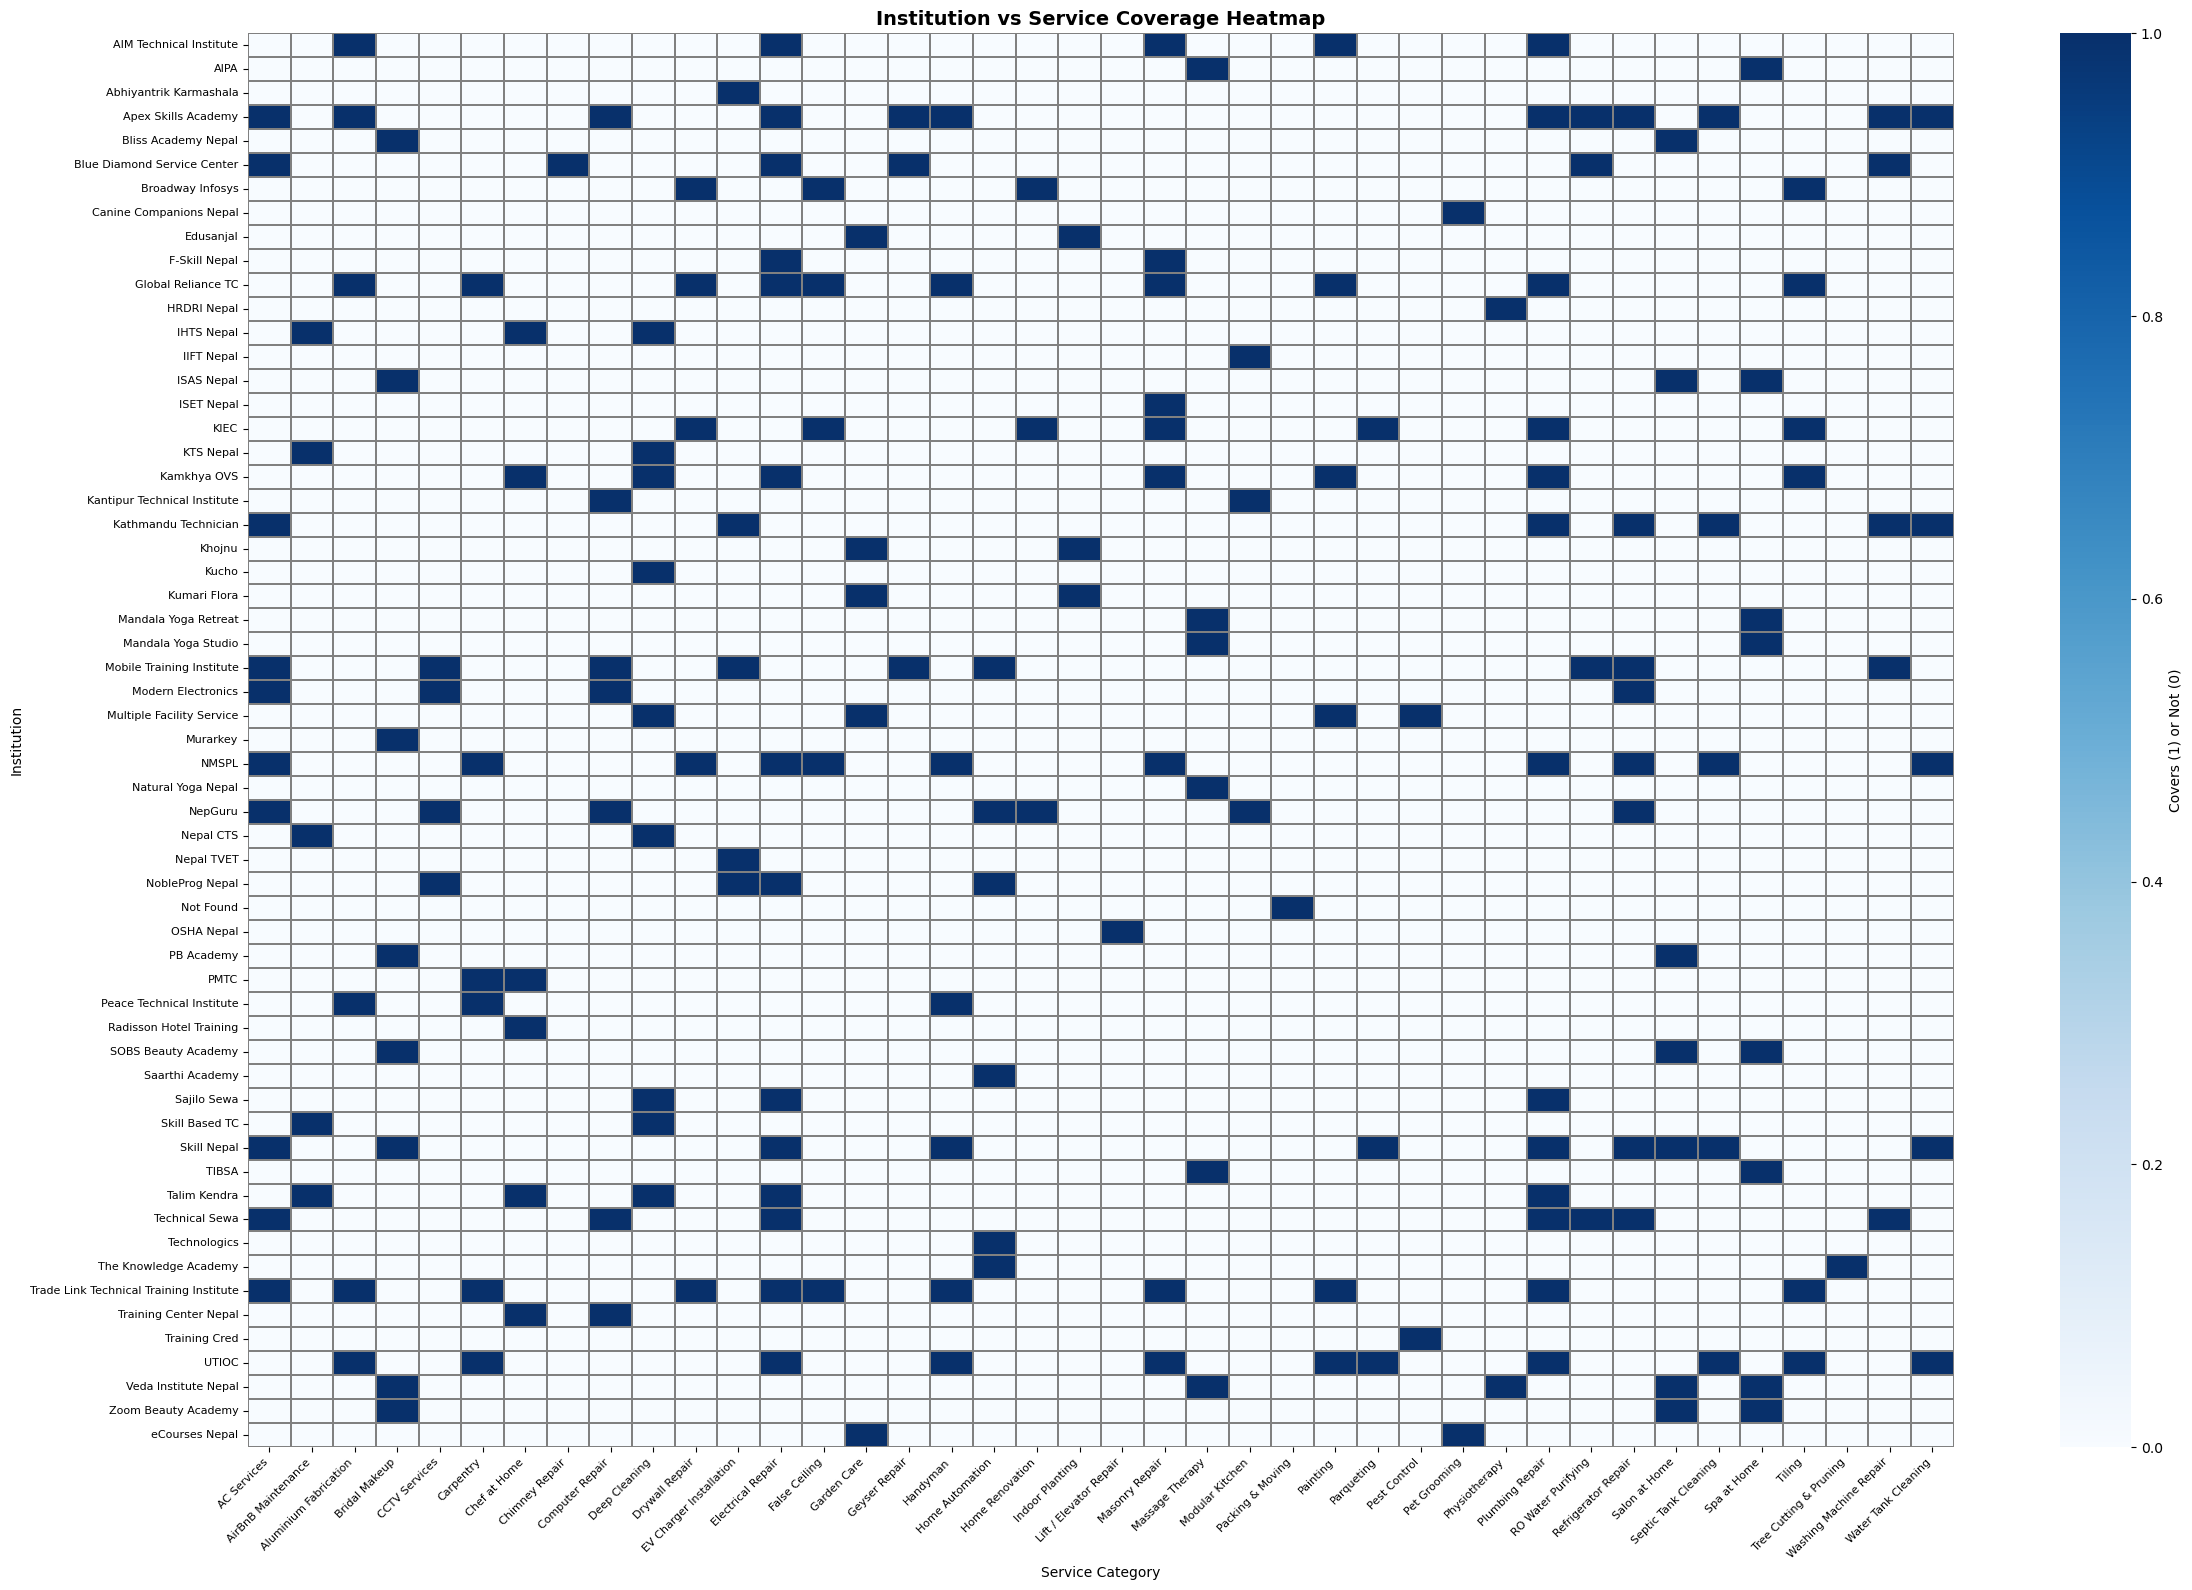

In [10]:
pivot = df.pivot_table(index="Institution", columns="Service", aggfunc="size", fill_value=0)

plt.figure(figsize=(24, 16))
sns.heatmap(pivot, cmap="Blues", linewidths=0.3, linecolor="gray", cbar_kws={"label": "Covers (1) or Not (0)"})

plt.title("Institution vs Service Coverage Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Service Category")
plt.ylabel("Institution")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("chart7.png", dpi=150, bbox_inches="tight")
plt.show()